In [37]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

np.set_printoptions(precision=2)

In [38]:
# 3*4 向量组
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

# 预设最优参数
b_init = 785.1811367994083
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [39]:
"""循环单样本测试"""


def predict_single_loop(x, w, b):
    n = x.shape[0]
    result = 0
    for i in range(n):
        p = w[i] * x[i]
        result += p
    result += b
    return result

In [40]:
# 测试predict_single_loop
x_vec = X_train[0, :]
f_wb1 = predict_single_loop(x_vec, w_init, b_init)
print(f_wb1)

459.9999976194083


In [41]:
"""向量化版本"""


def predict(x, w, b):
    p = np.dot(x, w) + b
    return p

In [42]:
# 测试predict
x_vec = X_train[0, :]
f_wb2 = predict(x_vec, w_init, b_init)
print(f_wb2)

459.9999976194083


In [43]:
"""多变量代价函数"""


def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = predict(x[i], w, b)
        cost += (f_wb_i - y[i]) ** 2
    cost /= 2 * m
    return cost

In [44]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(cost)

1.5578904428966628e-12


In [45]:
"""双重循环,计算偏导数"""


def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    for i in range(m):
        err = np.dot(x[i], w) + b - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * x[i][j]
        dj_db = dj_db + err
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [46]:
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(tmp_dj_db)  # 接近 -1.67e-6
print(tmp_dj_dw)  # 接近 [-2.73e-3, -6.27e-6, -2.22e-6, -6.92e-5]

[-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]
-1.6739251501955248e-06


In [47]:
"""多变量梯度下降"""


def gradient_descent(
    X, Y, w_init, b_init, cost_function, gradient_function, alpha, num_iters
):
    j_history = []
    w = copy.deepcopy(w_init)
    b = b_init
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(X, Y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 1000:
            j_history.append(cost_function(X, Y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
    return w, b, j_history

In [48]:
initial_w = np.zeros_like(w_init)  # [0,0,0,0]
initial_b = 0.0
iterations = 1000
alpha = 5.0e-7
w_final, b_final, J_hist = gradient_descent(
    X_train,
    y_train,
    initial_w,
    initial_b,
    compute_cost,
    compute_gradient,
    alpha,
    iterations,
)

Iteration    0: Cost  2529.46
Iteration  100: Cost   695.99
Iteration  200: Cost   694.92
Iteration  300: Cost   693.86
Iteration  400: Cost   692.81
Iteration  500: Cost   691.77
Iteration  600: Cost   690.73
Iteration  700: Cost   689.71
Iteration  800: Cost   688.70
Iteration  900: Cost   687.69


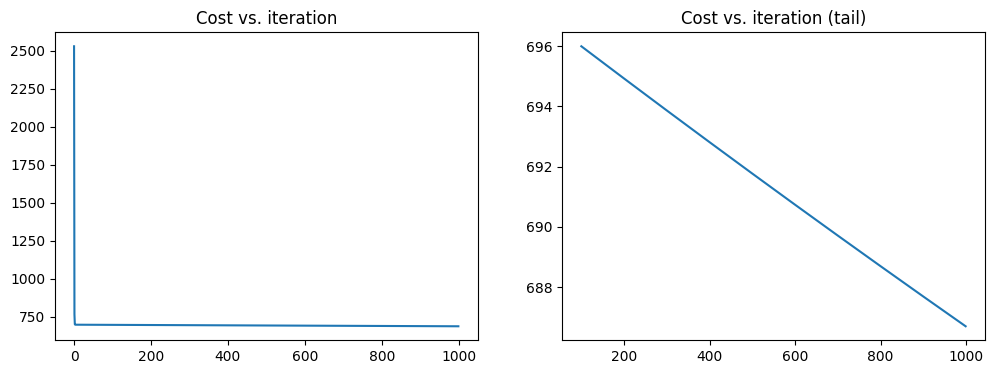

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration")
ax2.set_title("Cost vs. iteration (tail)")
plt.show()